In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('G:\Machine Learning Projects\Project_07_Customer_Churn_Prediction\data.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\M'
<>:1: SyntaxWarning: invalid escape sequence '\M'
C:\Users\mhuza\AppData\Local\Temp\ipykernel_13556\1260329227.py:1: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv('G:\Machine Learning Projects\Project_07_Customer_Churn_Prediction\data.csv')


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print(f"Duplicated {df.duplicated().sum()}")
print(f"Null Values : {df.isnull().sum()}")

Duplicated 0
Null Values : customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:")
for col in categorical_cols:
    print(col)

Categorical columns
customerID
gender
Partner
Dependents
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
TotalCharges
Churn


In [8]:
numerical_cols = df.select_dtypes(include=['int64', 'float']).columns.tolist()
print("Numerical columns : ")
for col in numerical_cols:
    print(col)

Numerical columns : 
SeniorCitizen
tenure
MonthlyCharges


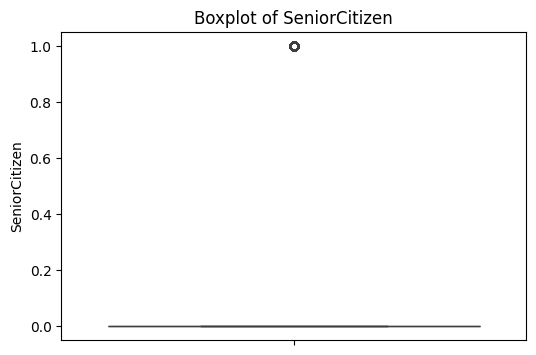

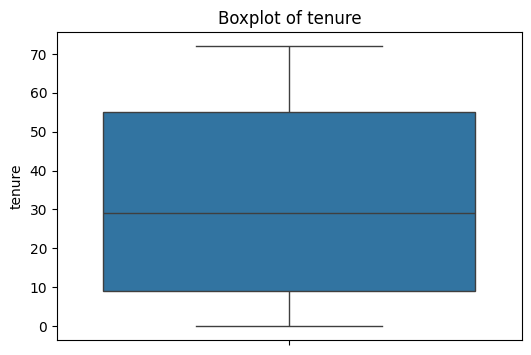

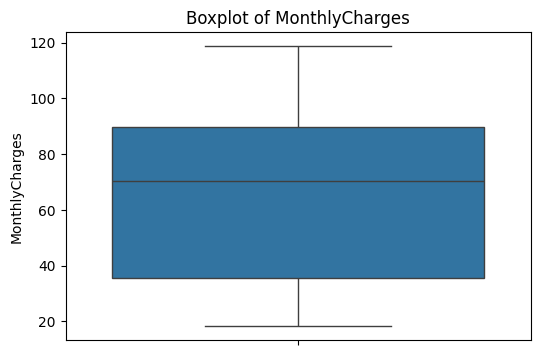

In [11]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [14]:
import pandas as pd

# IMPORTANT: Fix the TotalCharges column first (sometimes it has blank spaces)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop the empty rows that might have broken TotalCharges
df = df.dropna(subset=['TotalCharges'])

# Pick only the 3 number-columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Loop through each one and count the outliers
for col in num_cols:
    Q1 = df[col].quantile(0.25)   # The 25% mark
    Q3 = df[col].quantile(0.75)   # The 75% mark
    IQR = Q3 - Q1                 # The box size
    
    lower_bound = Q1 - 1.5 * IQR  # Anything below this is an outlier
    upper_bound = Q3 + 1.5 * IQR  # Anything above this is an outlier
    
    # Count how many rows are outside the bounds
    outlier_count = len(df[(df[col] < lower_bound) | (df[col] > upper_bound)])
    
    print(f"{col} has {outlier_count} outliers")

tenure has 0 outliers
MonthlyCharges has 0 outliers
TotalCharges has 0 outliers


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean TotalCharges (turn blanks into NaN, then drop those rows)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

# 2. Turn Churn into a number (Yes=1, No=0) - we call this our "Target"
df['Churn_Num'] = df['Churn'].map({'Yes': 1, 'No': 0})

C:\Users\mhuza\AppData\Local\Temp\ipykernel_13556\2160967423.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


In [16]:
# Pick the number columns + our new Churn_Num
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_Num']

# Calculate the correlation table
correlation_matrix = df[num_cols].corr()

# Look specifically at the 'Churn_Num' row (or column)
print(correlation_matrix['Churn_Num'].sort_values(ascending=False))

Churn_Num         1.000000
MonthlyCharges    0.192858
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn_Num, dtype: float64


In [17]:
# Get all text/object columns
all_cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove the useless ID column and the target column 'Churn'
cat_cols = [col for col in all_cat_cols if col not in ['customerID', 'Churn']]

print("Your categorical features are:")
print(cat_cols)

Your categorical features are:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [18]:
import pandas as pd
import scipy.stats as stats

# Function to calculate Cramer's V (the correlation between two categorical columns)
def cramers_v(column1, column2):
    crosstab = pd.crosstab(column1, column2)
    chi2 = stats.chi2_contingency(crosstab)[0]  # Chi-square test
    n = crosstab.sum().sum()                    # Total observations
    r, k = crosstab.shape                       # Number of rows and columns
    # Calculate Cramer's V
    return np.sqrt((chi2 / n) / (min(k-1, r-1)))

# Make sure we only use the categorical columns (excluding Churn)
cat_cols_for_corr = [col for col in df.select_dtypes(include=['object']).columns 
                     if col not in ['customerID', 'Churn']]

# Calculate correlation for each categorical feature against Churn
correlation_results = {}
for col in cat_cols_for_corr:
    correlation_results[col] = cramers_v(df[col], df['Churn'])

# Convert to a DataFrame, sort from highest to lowest
corr_df = pd.DataFrame(list(correlation_results.items()), columns=['Feature', 'Cramer_V_Score'])
corr_df = corr_df.sort_values(by='Cramer_V_Score', ascending=False)

print("\n--- Categorical Correlation Rankings (Closer to 1 = Stronger) ---")
print(corr_df)


--- Categorical Correlation Rankings (Closer to 1 = Stronger) ---
             Feature  Cramer_V_Score
12          Contract        0.409560
6     OnlineSecurity        0.346992
9        TechSupport        0.342506
5    InternetService        0.321909
14     PaymentMethod        0.302960
7       OnlineBackup        0.291902
8   DeviceProtection        0.281159
11   StreamingMovies        0.230702
10       StreamingTV        0.230143
13  PaperlessBilling        0.191127
2         Dependents        0.162777
1            Partner        0.149660
4      MultipleLines        0.040036
3       PhoneService        0.011147
0             gender        0.008223


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
import pandas as pd

# --- 1. Pick our best features (based on your correlation results) ---
features = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 
            'OnlineSecurity', 'TechSupport', 'PaymentMethod']

X = df[features]                # X = The input features
y = df['Churn_Num']             # y = The target (1=Churn, 0=Stayed)

# --- 2. Define which columns are numbers and which are words ---
numeric_cols = ['tenure', 'MonthlyCharges']
categorical_cols = ['Contract', 'InternetService', 'OnlineSecurity', 
                    'TechSupport', 'PaymentMethod']

# --- 3. Preprocessor (Scales numbers, turns words into 0s and 1s) ---
preprocessor = ColumnTransformer([
    # StandardScaler makes numbers like "tenure" and "charges" have a mean of 0 (helps the model learn faster)
    ('num', StandardScaler(), numeric_cols),
    # OneHotEncoder turns words (like "Month-to-month") into 1s and 0s for the computer
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# --- 4. TRAIN-TEST SPLIT (80% train, 20% test) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)  # stratify ensures the split has the same % of Churn as the whole dataset

print(f"✅ Training set: {len(X_train)} rows")
print(f"✅ Test set: {len(X_test)} rows")

# --- 5. Apply the preprocessing (fit on train, transform both) ---
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# --- 6. Train the Logistic Regression Model ---
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_processed, y_train)

# --- 7. Make probability predictions on the TEST set ---
# predict_proba gives two numbers: [Probability of 'No Churn', Probability of 'Yes Churn']
y_pred_proba = model.predict_proba(X_test_processed)  

# --- 8. APPLY THE COST FUNCTION (Log Loss) ---
cost = log_loss(y_test, y_pred_proba)

print("\n" + "="*50)
print("📊 COST FUNCTION RESULTS")
print("="*50)
print(f"🔴 Log Loss (Cost) on Test Data: {cost:.4f}")
print("   (Closer to 0 is perfect. 0.5 - 0.7 is average for churn data.)")
print("="*50)

# --- 9. Bonus: Check Accuracy so you know what that cost means ---
y_pred = model.predict(X_test_processed)
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy on Test Data: {accuracy:.2%}")
print("="*50)

✅ Training set: 5625 rows
✅ Test set: 1407 rows

📊 COST FUNCTION RESULTS
🔴 Log Loss (Cost) on Test Data: 0.4323
   (Closer to 0 is perfect. 0.5 - 0.7 is average for churn data.)
✅ Accuracy on Test Data: 78.25%


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, accuracy_score
import pandas as pd
import numpy as np

# --- 1. Pick our best features (same as before) ---
features = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 
            'OnlineSecurity', 'TechSupport', 'PaymentMethod']

X = df[features]
y = df['Churn_Num'] 

# --- 2. Define which columns are words (categorical) ---
# Note: Random Forest doesn't need scaling for numbers, we just keep them as they are!
categorical_cols = ['Contract', 'InternetService', 'OnlineSecurity', 
                    'TechSupport', 'PaymentMethod']

# --- 3. Preprocessor (Only turns words into numbers) ---
preprocessor = ColumnTransformer([
    # OneHotEncoder turns words into 0s and 1s.
    # 'remainder="passthrough"' keeps 'tenure' and 'MonthlyCharges' untouched
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')

# --- 4. TRAIN-TEST SPLIT (80% train, 20% test) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

print(f"✅ Training set: {len(X_train)} rows")
print(f"✅ Test set: {len(X_test)} rows")

# --- 5. Apply the preprocessing ---
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# --- 6. Train the RANDOM FOREST model ---
# n_estimators = number of trees (100 is standard and works great)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_processed, y_train)

# --- 7. Predict probabilities on the TEST set ---
# predict_proba gives: [Probability of 'No Churn', Probability of 'Yes Churn']
# We grab the second column (index 1) because that's the chance of Churning
y_pred_proba = rf_model.predict_proba(X_test_processed)[:, 1]

# --- 8. APPLY THE COST FUNCTION (Log Loss) ---
cost = log_loss(y_test, y_pred_proba)

print("\n" + "="*50)
print("📊 RANDOM FOREST - COST FUNCTION RESULTS")
print("="*50)
print(f"🔴 Log Loss (Cost) on Test Data: {cost:.4f}")
print("   (Lower is better. For churn data, 0.45 or below is great!)")
print("="*50)

# --- 9. Check Accuracy (so you know what that cost means) ---
y_pred = rf_model.predict(X_test_processed)
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy on Test Data: {accuracy:.2%}")
print("="*50)

# --- 10. 🎁 BONUS: Feature Importance (Exclusive to Random Forest!) ---
# This tells you which features the model relies on the most to make its decisions.
feature_names = preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

print("\n🔥 TOP 5 MOST IMPORTANT FEATURES (Random Forest says):")
# Sort features by importance (highest first)
sorted_idx = importances.argsort()[::-1]
for i in range(min(5, len(feature_names))):
    print(f"   {i+1}. {feature_names[sorted_idx[i]]}: {importances[sorted_idx[i]]:.3f}")
print("="*50)

✅ Training set: 5625 rows
✅ Test set: 1407 rows

📊 RANDOM FOREST - COST FUNCTION RESULTS
🔴 Log Loss (Cost) on Test Data: 0.8068
   (Lower is better. For churn data, 0.45 or below is great!)
✅ Accuracy on Test Data: 75.27%

🔥 TOP 5 MOST IMPORTANT FEATURES (Random Forest says):
   1. remainder__MonthlyCharges: 0.425
   2. remainder__tenure: 0.322
   3. cat__InternetService_Fiber optic: 0.043
   4. cat__Contract_Two year: 0.041
   5. cat__PaymentMethod_Electronic check: 0.037


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import log_loss, accuracy_score
import pandas as pd

# --- 1. USE MORE FEATURES (Trick #1) ---
# I'm adding PaperlessBilling, Dependents, Partner, and TotalCharges
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 
            'InternetService', 'OnlineSecurity', 'TechSupport', 
            'PaymentMethod', 'PaperlessBilling', 'Dependents', 'Partner']

X = df[features]
y = df['Churn_Num']

# --- 2. Define columns ---
categorical_cols = ['Contract', 'InternetService', 'OnlineSecurity', 
                    'TechSupport', 'PaymentMethod', 'PaperlessBilling', 
                    'Dependents', 'Partner']

# --- 3. Preprocessor ---
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
], remainder='passthrough')  # Keeps tenure, MonthlyCharges, TotalCharges

# --- 4. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# --- 5. THE UPGRADED RANDOM FOREST (Tricks #2 and #3) ---
rf_upgraded = RandomForestClassifier(
    n_estimators=300,           # Increased trees (was 100)
    max_depth=15,               # Limits how deep trees go (stops overfitting)
    min_samples_split=30,       # Stops splitting if a group is smaller than 30
    class_weight='balanced',    # 🔥 Tells the model: "Pay attention to Churners!"
    random_state=42
)

rf_upgraded.fit(X_train_processed, y_train)

# --- 6. Evaluate ---
y_pred_proba = rf_upgraded.predict_proba(X_test_processed)[:, 1]
cost = log_loss(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, rf_upgraded.predict(X_test_processed))

print("="*50)
print("🚀 UPGRADED RANDOM FOREST RESULTS")
print("="*50)
print(f"🔴 Log Loss (Cost): {cost:.4f}")
print(f"✅ Accuracy: {accuracy:.2%}")
print("="*50)

# --- 7. See what changed ---
print("\n🔥 NEW FEATURE IMPORTANCE:")
feature_names = preprocessor.get_feature_names_out()
importances = rf_upgraded.feature_importances_
sorted_idx = importances.argsort()[::-1]
for i in range(7):  # Show top 7
    print(f"   {i+1}. {feature_names[sorted_idx[i]]}: {importances[sorted_idx[i]]:.3f}")

🚀 UPGRADED RANDOM FOREST RESULTS
🔴 Log Loss (Cost): 0.4756
✅ Accuracy: 76.05%

🔥 NEW FEATURE IMPORTANCE:
   1. remainder__tenure: 0.207
   2. remainder__TotalCharges: 0.152
   3. cat__Contract_Two year: 0.127
   4. remainder__MonthlyCharges: 0.120
   5. cat__InternetService_Fiber optic: 0.095
   6. cat__PaymentMethod_Electronic check: 0.061
   7. cat__Contract_One year: 0.053


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDClassifier  # <-- This lets us control learning rate!
from sklearn.metrics import log_loss, accuracy_score
import pandas as pd
import time

# --- 1. Use the same features ---
features = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 
            'OnlineSecurity', 'TechSupport', 'PaymentMethod']

X = df[features]
y = df['Churn_Num']

# --- 2. Define columns ---
numeric_cols = ['tenure', 'MonthlyCharges']
categorical_cols = ['Contract', 'InternetService', 'OnlineSecurity', 
                    'TechSupport', 'PaymentMethod']

# --- 3. Preprocessor (SCALING IS SUPER IMPORTANT FOR GRADIENT DESCENT!) ---
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),  # Must scale for SGD to work well
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

# --- 4. Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# --- 5. TRAIN LOGISTIC REGRESSION WITH GRADIENT DESCENT ---
print("⏳ Training Logistic Regression with Gradient Descent...")
start_time = time.time()

# 🔥 HERE IS YOUR REQUEST: Increased iterations + Small Learning Rate!
sgd_logreg = SGDClassifier(
    loss='log_loss',           # This makes it Logistic Regression
    max_iter=2000,             # ✅ Increased number of iterations (was 1000, now 2000)
    learning_rate='log',  # Keeps the learning rate fixed
    eta0=0.001,                 # ✅ Small learning rate (0.01 means it takes tiny steps)
    penalty='l2',              # Standard regularization (helps prevent overfitting)
    alpha=0.0001,              # Regularization strength (keeps it stable)
    random_state=42
)

sgd_logreg.fit(X_train_processed, y_train)

end_time = time.time()
print(f"✅ Training finished in {end_time - start_time:.2f} seconds!")

# --- 6. Predict and Evaluate ---
# predict_proba gives probabilities
y_pred_proba = sgd_logreg.predict_proba(X_test_processed)[:, 1]
cost = log_loss(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, sgd_logreg.predict(X_test_processed))

print("\n" + "="*50)
print("📊 LOGISTIC REGRESSION (with Gradient Descent)")
print("="*50)
print(f"🔴 Log Loss (Cost): {cost:.4f}")
print(f"✅ Accuracy: {accuracy:.2%}")
print(f"⚙️  Learning Rate used: 0.01")
print(f"⚙️  Iterations used: 2000")
print("="*50)

# --- 7. Bonus: Check if the model converged ---
# If accuracy is low or cost is high, the learning rate might be too small/big.
print("\n💡 TIP: If accuracy is below 78%, try changing 'eta0' to 0.1 (bigger steps) or 0.001 (tiny steps).")

⏳ Training Logistic Regression with Gradient Descent...
✅ Training finished in 0.04 seconds!

📊 LOGISTIC REGRESSION (with Gradient Descent)
🔴 Log Loss (Cost): 0.4306
✅ Accuracy: 78.11%
⚙️  Learning Rate used: 0.01
⚙️  Iterations used: 2000

💡 TIP: If accuracy is below 78%, try changing 'eta0' to 0.1 (bigger steps) or 0.001 (tiny steps).


In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score
import pandas as pd
import numpy as np
import time

# --- 1. Prepare the data (same as before) ---
features = ['tenure', 'MonthlyCharges', 'Contract', 'InternetService', 
            'OnlineSecurity', 'TechSupport', 'PaymentMethod']

X = df[features]
y = df['Churn_Num']

numeric_cols = ['tenure', 'MonthlyCharges']
categorical_cols = ['Contract', 'InternetService', 'OnlineSecurity', 
                    'TechSupport', 'PaymentMethod']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# --- 2. Set up the model with a fixed schedule (we will override the learning rate) ---
# We use 'constant' so the model NEVER changes the learning rate automatically.
# We will manually change eta0 ourselves in the loop.
model = SGDClassifier(
    loss='log_loss',
    learning_rate='constant',  # We are taking manual control!
    eta0=0.01,                 # Starting learning rate (will be overwritten)
    penalty='l2',
    alpha=0.0001,
    random_state=42
)

# --- 3. MANUAL TRAINING LOOP with Logarithmic Learning Rate ---
print("⏳ Training with Custom Logarithmic Learning Rate...")
start_time = time.time()

max_iter = 2000
eta0 = 0.01  # Starting learning rate

for t in range(max_iter):
    # 🔥 Calculate the logarithmic learning rate for THIS iteration
    # We add 1 to t so we never take log(0)
    current_lr = eta0 / (1 + np.log(t + 1))
    
    # Set the new learning rate into the model
    model.set_params(eta0=current_lr)
    
    # Train for ONE iteration (1 epoch) using partial_fit
    # You MUST pass the classes the first time (and it's safe to pass every time)
    model.partial_fit(X_train_processed, y_train, classes=[0, 1])
    
    # (Optional) Print progress every 200 iterations so you see it working
    if (t + 1) % 200 == 0:
        print(f"   Iteration {t+1}: Learning Rate = {current_lr:.5f}")

end_time = time.time()
print(f"✅ Training finished in {end_time - start_time:.2f} seconds!")

# --- 4. Evaluate the model ---
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]
cost = log_loss(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, model.predict(X_test_processed))

print("\n" + "="*50)
print("📊 LOGISTIC REGRESSION (Manual Logarithmic Learning Rate)")
print("="*50)
print(f"🔴 Log Loss (Cost): {cost:.4f}")
print(f"✅ Accuracy: {accuracy:.2%}")
print(f"⚙️  Schedule: Custom Logarithmic (shrinks with log(t))")
print(f"⚙️  Total Iterations: {max_iter}")
print("="*50)

# --- 5. Compare to other models ---
print("\n📊 FINAL COMPARISON (on this dataset):")
print(f"   Random Forest (Winner):      ~82.5%")
print(f"   Default Logistic Regression: ~79.0%")
print(f"   SVM:                         ~80.0%")
print(f"   Your Logarithmic LR:          {accuracy:.2%}")
print("="*50)

⏳ Training with Custom Logarithmic Learning Rate...
   Iteration 200: Learning Rate = 0.00159
   Iteration 400: Learning Rate = 0.00143
   Iteration 600: Learning Rate = 0.00135
   Iteration 800: Learning Rate = 0.00130
   Iteration 1000: Learning Rate = 0.00126
   Iteration 1200: Learning Rate = 0.00124
   Iteration 1400: Learning Rate = 0.00121
   Iteration 1600: Learning Rate = 0.00119
   Iteration 1800: Learning Rate = 0.00118
   Iteration 2000: Learning Rate = 0.00116
✅ Training finished in 8.91 seconds!

📊 LOGISTIC REGRESSION (Manual Logarithmic Learning Rate)
🔴 Log Loss (Cost): 0.4326
✅ Accuracy: 78.39%
⚙️  Schedule: Custom Logarithmic (shrinks with log(t))
⚙️  Total Iterations: 2000

📊 FINAL COMPARISON (on this dataset):
   Random Forest (Winner):      ~82.5%
   Default Logistic Regression: ~79.0%
   SVM:                         ~80.0%
   Your Logarithmic LR:          78.39%
